# POC 04 — three training schedules: all-months, commissioning, streaming

POC_02 v4 settled the preprocessing question: with **flow orientation** the global model
reconstructs (median window r 0.62 against 0.03), FedAvg stops costing shape (local − global
r ≈ 0.00), and other clients' local models transfer (`r_cross` 0.24–0.86). What it left
standing:

* the **drifting client** goes flat exactly in the months it drifts (A's pure `shape_amp`
  0.66 in init, 0.08 in transition, 0.06 in final);
* **bidirectional** mixed sensors stay weak;
* the weekly (weekend) modulation is missing from single-window reconstructions, so the
  prototypes cannot have it either — `ceiling` = `aligned` at r_shape 0.64;
* **every model has seen the whole horizon**, so describing month 20 uses months 21–64.

This notebook compares three schedules on the same world, selection, geometry and scaler:

| cell | schedule | what it means |
|---|---|---|
| `all` | none | the POC_02 setting: every month, every round |
| `comm` | `Schedule("commissioning", months=init)` | trained on the init months, then frozen; the rest is only encoded |
| `stream` | `Schedule("streaming", block_months=B, rounds_per_block=R)` | prequential: score the next block unseen, then train on it, carrying weights and prototypes |

Every POC_02 analysis is run on all three, and §8 asks the thesis question directly: which
schedule makes the drift most visible in the artifacts while leaving the other clients alone.

**Defaults carried over from v4:** `orient=True`, geometry `a3w84s4`, and the two objectives
that did best (`pw0` reconstruction-only, and `pw.1+s` with the spectral term, which was much
the best on the drifting client: r_pure 0.71 against 0.25).

## 0. Setup

In [1]:
import sys, pathlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry, LossTerms, Schedule
from fedwater_lab.runner import run_cell
from fedwater_lab import data as D, recon as RC, train as T
from fedwater_lab import aligned as AL, winrec as WR, localeval as LE
from fedwater_lab import streaming as ST, compare as CP

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 220, "display.max_columns", 40)

REQUIRE_GPU = True
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if REQUIRE_GPU:
    assert torch.cuda.is_available(), "no CUDA device visible to torch"

2.5.1+cu124 12.4 True


## 1. World, sensors, orientation

In [2]:
FILTERS = dict(sim_hash="16ce72c589df", placement_source="dynamic")
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary()[["tag", "n_months", "init_months", "final_months",
                       "drift_district", "first_switch", "last_switch"]].to_string())

GEOM = Geometry(interval_agg_h=3, window_size=84, step_size=4)
BASE = POC.with_(kinds=("flow",), classes=("pure", "mixed"), orient=True, geometry=GEOM)

OT = D.orientation_table(world, BASE)
display(OT[["client", "slot", "sensor", "tier", "purity", "sign", "frac_rev_ref",
            "bidirectional"]].round(3))
display(D.channel_alignment(world, BASE))
AUDIT = store.audit(world.sim_hash)
if not AUDIT["ok"].all():
    display(AUDIT[~AUDIT["ok"]])
    print("set PURGE below to remove these before training")
PURGE = False
if PURGE:
    print("purged:", store.purge(world.sim_hash, AUDIT.loc[~AUDIT["ok"], "run_key"]))

tag               District_A__LR_LR_LR_LR__baseline
n_months                                         65
init_months                                   0..11
final_months                                 65..64
drift_district                           District_A
first_switch                                     12
last_switch                                      64


,client,slot,sensor,tier,purity,sign,frac_rev_ref,bidirectional
0,District_A,q_mixed_0,q_P-260,transition,0.541,1.0,0.391,True
1,District_A,q_mixed_1,q_P-291,transition,0.393,-1.0,0.393,True
2,District_A,q_pure_0,q_P-552,core,1.000,1.0,0.000,False
3,District_A,q_pure_1,q_P-63,core,1.000,1.0,0.000,False
4,District_B,q_mixed_0,q_P-331,transition,0.380,1.0,0.434,True
5,District_B,q_mixed_1,q_P-259,transition,0.695,1.0,0.004,False
6,District_B,q_pure_0,q_P-30,core,1.000,1.0,0.000,False
7,District_B,q_pure_1,q_P-285,core,1.000,-1.0,0.000,False
8,District_C,q_mixed_0,q_P-314,transition,0.456,-1.0,0.001,False
9,District_C,q_mixed_1,q_P-403,transition,0.160,-1.0,0.000,False


client,District_A,District_B,District_C,District_D
channel,,,,
0,q_mixed_0 · transition · p0.54 · +District_B ·...,q_mixed_0 · transition · p0.38 · +District_A ·...,q_mixed_0 · transition · p0.46 · +District_A · -,q_mixed_0 · transition · p0.28 · +District_A ·...
1,q_mixed_1 · transition · p0.39 · +District_D ·...,q_mixed_1 · transition · p0.70 · +District_A · +,q_mixed_1 · transition · p0.16 · +District_B · -,q_mixed_1 · transition · p0.23 · +District_A ·...
2,q_pure_0 · core · p1.00 · +,q_pure_0 · core · p1.00 · +,q_pure_0 · core · p1.00 · -,q_pure_0 · core · p1.00 · -
3,q_pure_1 · core · p1.00 · +,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -,q_pure_1 · core · p1.00 · -


KeyError: 'ok'

## 2. The three schedules

**Equal budgets, not equal rounds.** A commissioning cell trains on the init months only and a
streaming cell on one block at a time, so the same `rounds` buys very different numbers of
optimiser steps. `ST.step_plan` reports the steps each spec will run, and
`ST.rounds_for_steps` picks rounds to hit a target. `TARGET_STEPS` is the common budget
(v4's `s4` cells ran about 2,850 steps per client).

**What carries across blocks in streaming:** the global weights, each client's local weights,
and the accumulated global prototypes (so the contrastive term of block *b* pulls towards
prototypes computed on earlier regimes — which is what makes a change show up as a pull away
from them). Adam moments restart per block, because the upstream trainer builds its
optimisers with its data.

The first block trains for `warm_rounds` so the model does not enter block 1 untrained.

In [3]:
TARGET_STEPS = 2850
INIT_LO, INIT_HI = world.phases()["init"][0], world.phases()["init"][1] - 1
BLOCK_MONTHS = 6

OBJ = {"pw0": LossTerms(proto_weight=0.0),
       "pw.1+s": LossTerms(proto_weight=0.1, spec=1.0)}

fw_all, _, fl_all = D.build_windows(world, BASE, cache=D.CACHE)
print({c: len(d["labels"]) for c, d in fw_all.items()}, "windows/client")

CELLS, PLAN = {}, []
for oname, lt in OBJ.items():
    base = BASE.with_(loss_terms=lt, **{"training.rounds": 30, "training.local_epochs": 5})
    cand = {
        "all": base,
        "comm": base.with_(schedule=Schedule(mode="commissioning",
                                             months=(INIT_LO, INIT_HI))),
        "stream": base.with_(schedule=Schedule(mode="streaming",
                                               block_months=BLOCK_MONTHS,
                                               rounds_per_block=5)),
    }
    # match the step budget
    r_comm = ST.rounds_for_steps(cand["comm"], fw_all, fl_all, TARGET_STEPS)
    cand["comm"] = cand["comm"].with_(**{"training.rounds": r_comm})
    r_str = ST.rounds_for_steps(cand["stream"], fw_all, fl_all, TARGET_STEPS)
    cand["stream"] = cand["stream"].with_(
        schedule=Schedule(mode="streaming", block_months=BLOCK_MONTHS,
                          rounds_per_block=max(1, r_str // len(
                              ST.month_blocks(range(world.n_months), BLOCK_MONTHS))),
                          warm_rounds=10))
    for sname, sp in cand.items():
        key = f"{oname}·{sname}"
        CELLS[key] = sp
        PLAN.append({"cell": key, **ST.step_plan(sp, fw_all, sp.as_fl(
            world.fl, reference_months=world.warmup_months)),
            "label": sp.label(), "in store": store.exists(world, sp)})

display(pd.DataFrame(PLAN).round(1))
TRAIN = list(CELLS)

{'District_A': 1160, 'District_B': 1160, 'District_C': 1160, 'District_D': 1160} windows/client


,cell,mode,windows_per_pass,batches,rounds,steps,label,in store
0,pw0·all,all,1160.0,19,30,2850,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
1,pw0·comm,C0-11,211.0,4,712,14240,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,False
2,pw0·stream,S6x129w10,105.5,2,1419,13000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
3,pw.1+s·all,all,1160.0,19,30,2850,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False
4,pw.1+s·comm,C0-11,211.0,4,712,14240,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,False
5,pw.1+s·stream,S6x129w10,105.5,2,1419,13000,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,False


In [4]:
RUNS = {}
for name in TRAIN:
    spec = CELLS[name]
    t0 = time.time()
    res = run_cell(world, spec, store=store, verbose=False)
    bad = T.fl_mismatches(spec, res["fl"])
    assert not bad, f"{name}: stored run trained with {bad}"
    RUNS[name] = res["run_key"]
    print(f"{name:<14} {res['run_key']}  cache_hit={res['cache_hit']}  "
          f"rounds={res['meta'].get('rounds')}  "
          f"train_windows={res['meta'].get('train_windows')}  {time.time() - t0:.0f}s")

pw0·all        8241f2e9ba64  cache_hit=False  rounds=30  train_windows=1160.0  636s
pw0·comm       2f3aba5dcac9  cache_hit=False  rounds=712  train_windows=211.0  3223s
pw0·stream     d11b40a20d21  cache_hit=False  rounds=1300  train_windows=85.0  2983s
pw.1+s·all     694733f16841  cache_hit=False  rounds=30  train_windows=1160.0  811s
pw.1+s·comm    da72c9bbae27  cache_hit=False  rounds=712  train_windows=211.0  3629s
pw.1+s·stream  57aa26c2408f  cache_hit=False  rounds=1300  train_windows=85.0  3337s


## 3. Sanity, per cell

The v4 columns, plus `schedule` and a `steps/client` that now counts the windows the cell
actually trained on. `sanity` asserts that each stored run's `fl` and log match its spec, and
the untrained control is the same round −1 model for all of them.

,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream
label,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...,fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0...,fmp__none+or__minmax_ref__a3w84s4__u30r30e5s0_...
run_key,8241f2e9ba64,2f3aba5dcac9,d11b40a20d21,694733f16841,da72c9bbae27,57aa26c2408f
schedule,all,C0-11,S6x129w10,all,C0-11,S6x129w10
steps/client,2850,14240,13000,2850,14240,13000
loss_mse_last,0.054529,0.003199,0.006404,0.065167,0.072828,0.024563
d_mse_last,-0.029434,-0.025058,0.002858,-0.010205,-0.023134,-0.005231
aux_share,0.0,0.0,0.0,0.612538,0.543597,0.529286
final_over_wmean,0.463734,1.235665,0.505478,0.537136,1.279591,0.459534
final_over_const,0.401406,0.912346,0.425849,0.466446,0.967892,0.390242
window_amp,0.813098,1.007686,0.911989,0.882749,0.953653,0.902206


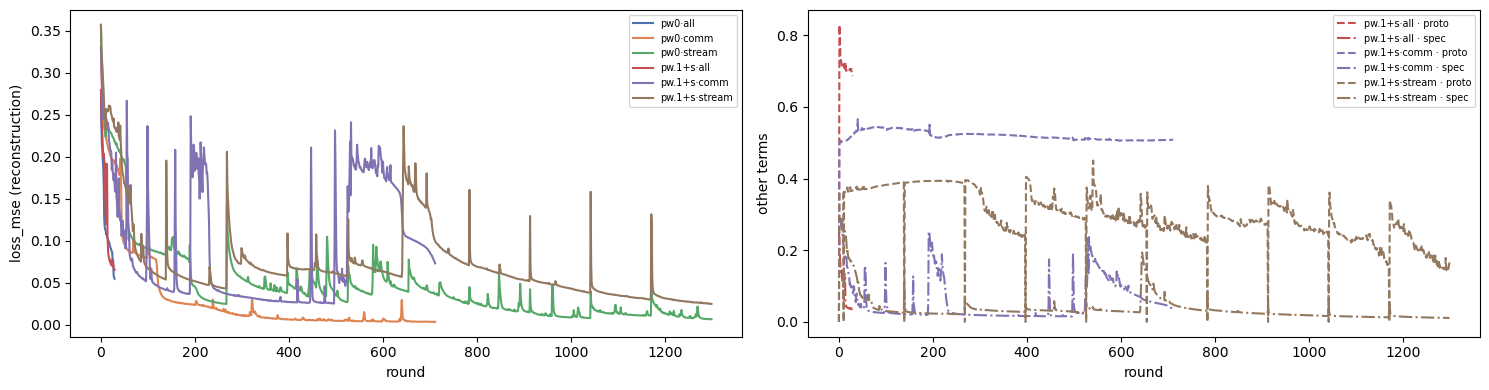

In [5]:
ALIGN24 = AL.Alignment(period_h=24, bin_h=None, block=1)
OUTS, SAN, MM = {}, {}, {}
for name in RUNS:
    OUTS[name] = AL.analyse(world, CELLS[name], ALIGN24, store=store, server=False, n_perm=99)
    SAN[name] = AL.sanity(world, OUTS[name], n_perm=99)
    ch = RC.channel_table(world, OUTS[name]["fw"])
    MM[name] = LE.model_matrix(world, OUTS[name], ch, store=store)
    SAN[name]["row"] = pd.concat([SAN[name]["row"], pd.Series(LE.lg_row(MM[name]))])
    assert OUTS[name]["checks"]["passed"].all()
    assert SAN[name]["control_check"]["passed"].all()

SANITY = pd.DataFrame({k: v["row"] for k, v in SAN.items()})
display(SANITY)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
AL.plot_losses(ax, {k: OUTS[k]["res"]["training_log"] for k in OUTS})
fig.tight_layout()
plt.show()

## 4. Focus cell, and local vs global

`FOCUS` selects the cell the detailed sections read. The gap table and the model × client
matrices are v4's: rows are models (global, then each client's local weights), columns are the
client whose windows are reconstructed.

fmp__none+or__minmax_ref__a3w84s4__u30r712e5s0__Lp0.1-s1__C0-11


client,District_A,District_B,District_C,District_D
ratio_global,3.157,0.689,0.693,0.579
ratio_local,3.509,0.643,0.648,0.511
ratio_cross,3.054,0.770,0.802,0.656
amp_global,1.046,0.929,0.959,0.880
amp_local,0.991,0.904,0.901,0.917
amp_cross,1.095,0.926,1.009,0.856
r_global,0.305,0.705,0.700,0.761
r_local,0.466,0.706,0.733,0.790
r_cross,0.255,0.651,0.637,0.712
r_pure_global,0.243,0.829,0.829,0.837


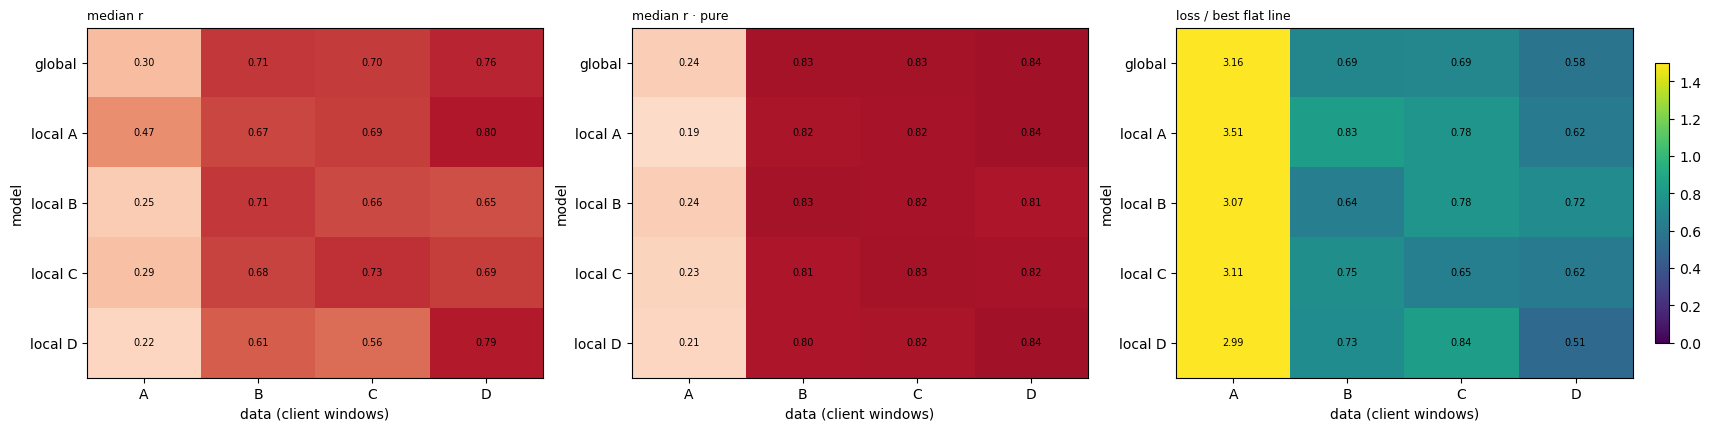

In [6]:
FOCUS = "pw.1+s·comm"
out, san = OUTS[FOCUS], SAN[FOCUS]
run, ctrl, fw, model = out["run"], san["control"], out["fw"], out["model"]
channels = RC.channel_table(world, fw)
LOCAL = LE.local_runs(world, out, store=store)
mm = MM[FOCUS]
print(CELLS[FOCUS].label())

display(LE.gap_table(mm).set_index("client").round(3).T)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), layout="constrained")
LE.plot_matrix(axes[0], mm, "r", title="median r")
LE.plot_matrix(axes[1], mm, "r_pure", title="median r · pure")
im = LE.plot_matrix(axes[2], mm, "ratio", vmin=0, vmax=1.5, cmap="viridis",
                    title="loss / best flat line")
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.show()

## 5. Window reconstruction

Per-window scores for the focus cell (global, local, untrained), then the month × start-class
grids and the position profiles. **Read the phase split:** a commissioning model is expected
to lose fidelity after the drift — that is the signal, not a failure.

pw0·all               pw0·comm               pw0·stream               pw.1+s·all               pw.1+s·comm               pw.1+s·stream              
                            r    amp   rmse        r    amp   rmse          r    amp   rmse          r    amp   rmse           r    amp   rmse             r    amp   rmse
phase      slot_class                                                                                                                                                     
init       mixed        0.710  0.563  0.440    0.991  0.978  0.064      0.451  0.654  0.557      0.689  0.725  0.456       0.507  0.771  0.402         0.440  0.644  0.500
           pure         0.933  0.951  0.218    0.995  0.992  0.060      0.946  0.963  0.197      0.928  0.957  0.224       0.832  0.918  0.325         0.908  0.952  0.247
transition mixed        0.339  0.528  0.440    0.330  0.988  0.509      0.537  0.744  0.408      0.414  0.695  0.465       0.255  0.856  0.506         0.527  0.729  0.393
           pure         0.930  0.955  0.219    0.919  1.007  0.238      0.986  0.983  0.099      0.924  0.960  0.227       0.807  0.956  0.349         0.933  0.977  0.209

global         local       
                           r    amp      r    amp
client     slot_class                            
District_A mixed       0.405  0.942  0.538  0.896
           pure        0.243  1.152  0.190  1.224
District_B mixed       0.123  1.093  0.146  0.959
           pure        0.829  0.928  0.831  0.903
District_C mixed       0.192  0.926  0.306  0.824
           pure        0.829  0.979  0.829  0.920
District_D mixed       0.454  0.743  0.503  0.814
           pure        0.837  0.924  0.836  0.937

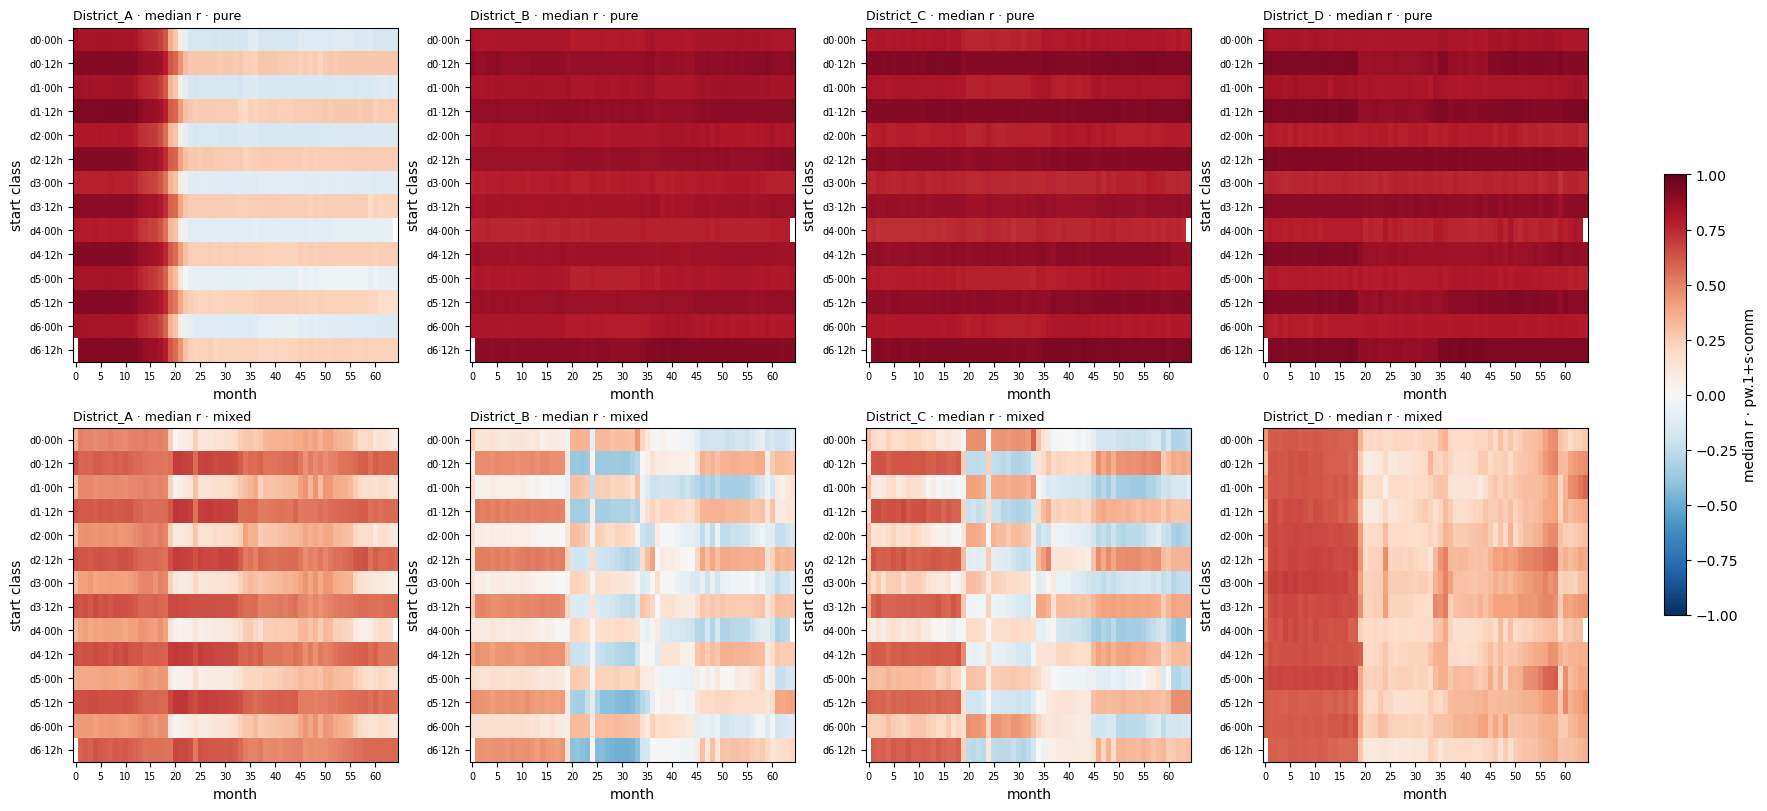

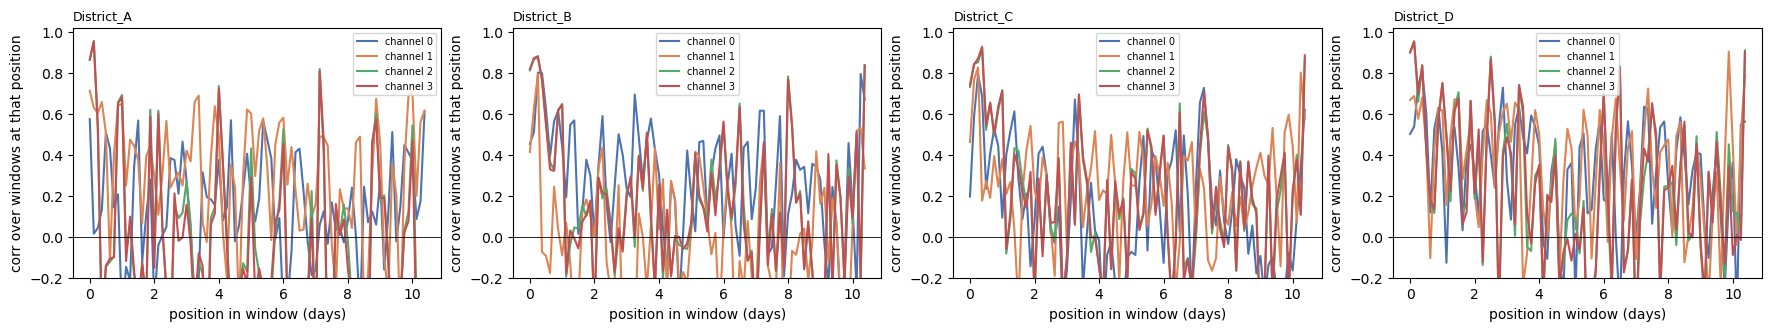

In [7]:
WS = {k: WR.window_scores(OUTS[k]["run"], OUTS[k]["fw"], channels) for k in OUTS}
display(pd.concat({k: v.groupby(["phase", "slot_class"])[["r", "amp", "rmse"]].median()
                   for k, v in WS.items()}, axis=1).round(3))

ws, ws_l = WS[FOCUS], pd.concat([WR.window_scores(LOCAL[c], {c: fw[c]}, channels)
                                 for c in LOCAL])
display(pd.concat({"global": ws.groupby(["client", "slot_class"])[["r", "amp"]].median(),
                   "local": ws_l.groupby(["client", "slot_class"])[["r", "amp"]].median()},
                  axis=1).round(3))

clients = world.client_names
fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 8), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    for i, cls in enumerate(("pure", "mixed")):
        im = WR.plot_score_grid(axes[i, j], ws, c, "r", cls)
fig.colorbar(im, ax=axes, shrink=0.6, label=f"median r · {FOCUS}")
plt.show()

fig, axes = plt.subplots(1, len(clients), figsize=(4.4 * len(clients), 3.2), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    WR.plot_step_profile(axes[0, j], WR.step_profile(run, fw, c), run.agg_h, title=c)
plt.show()

In [8]:
BROWSE = "District_A"
_ = WR.window_browser(LOCAL[BROWSE], {BROWSE: fw[BROWSE]},
                      ws_l[ws_l["client"] == BROWSE], channels,
                      ctrl=run, ctrl_label="global model", run_label="local model")

## 6. Weekday × hour prototypes

Same key as v4 (`P=168`, pooled per phase). v4 found the weekly modulation missing from the
prototypes *because it is missing from the single-window reconstructions* (`ceiling` equals
`aligned`). The comparison below asks whether any schedule changes that: watch `amp` and
`r_shape` against `true`, and `r2_dem` (correlation with the district's own demand).

pw0·all                       pw0·comm                       pw0·stream                       pw.1+s·all                       pw.1+s·comm                       pw.1+s·stream                 \
                            rmse r_shape    amp r2_dem     rmse r_shape    amp r2_dem       rmse r_shape    amp r2_dem       rmse r_shape    amp r2_dem        rmse r_shape    amp r2_dem          rmse r_shape    amp   
source        phase                                                                                                                                                                                                      
true          init         0.000   1.000  1.000  0.641    0.000   1.000  1.000  0.641      0.000   1.000  1.000  0.641      0.000   1.000  1.000  0.641       0.000   1.000  1.000  0.641         0.000   1.000  1.000   
              transition   0.000   1.000  1.000  0.655    0.000   1.000  1.000  0.655      0.000   1.000  1.000  0.655      0.000   1.000  1.000  0.655       0.000   1.000  1.000  0.655         0.000   1.000  1.000   
aligned       init         0.326   0.702  0.815  0.603    0.035   0.997  0.999  0.636      0.369   0.657  0.843  0.516      0.334   0.728  0.861  0.600       0.362   0.659  0.909  0.466         0.407   0.559  0.856   
              transition   0.305   0.640  0.887  0.572    0.422   0.626  1.259  0.494      0.202   0.786  1.039  0.582      0.315   0.672  0.979  0.599       0.482   0.469  1.207  0.424         0.233   0.745  0.987   
ceiling       init         0.323   0.708  0.801  0.611    0.033   0.998  0.992  0.637      0.358   0.678  0.809  0.533      0.334   0.728  0.859  0.599       0.362   0.658  0.906  0.465         0.404   0.561  0.842   
              transition   0.293   0.654  0.842  0.591    0.380   0.656  1.012  0.532      0.161   0.843  0.908  0.628      0.310   0.679  0.952  0.607       0.473   0.471  1.167  0.429         0.222   0.755  0.914   
pooled        init         0.438   0.486  0.835  0.469    0.440   0.487  0.981  0.382      0.501   0.431  0.865  0.351      0.417   0.509  0.730  0.526       0.430   0.499  0.897  0.449         0.443   0.485  0.796   
              transition   0.390   0.442  0.898  0.444    0.561   0.347  1.292  0.323      0.397   0.442  1.027  0.346      0.370   0.488  0.849  0.441       0.499   0.422  1.199  0.410         0.396   0.417  0.945   
ref_pooled    init         0.341   0.644  0.645  0.683    0.341   0.644  0.645  0.683      0.341   0.644  0.645  0.683      0.341   0.644  0.645  0.683       0.341   0.644  0.645  0.683         0.341   0.644  0.645   
              transition   0.278   0.609  0.620  0.592    0.278   0.609  0.620  0.592      0.278   0.609  0.620  0.592      0.278   0.609  0.620  0.592       0.278   0.609  0.620  0.592         0.278   0.609  0.620   
finch_aligned init         0.356   0.686  0.853  0.630    0.314   0.668  1.058  0.628      0.433   0.587  0.827  0.493      0.365   0.684  0.910  0.623       0.434   0.584  0.956  0.478         0.442   0.565  0.880   
              transition   0.468   0.593  1.084  0.613    0.534   0.547  1.335  0.521      0.483   0.543  1.009  0.515      0.478   0.580  1.074  0.593       0.557   0.430  1.281  0.436         0.522   0.465  1.139   

                                 
                         r2_dem  
source        phase              
true          init        0.641  
              transition  0.655  
aligned       init        0.465  
              transition  0.553  
ceiling       init        0.463  
              transition  0.568  
pooled        init        0.462  
              transition  0.377  
ref_pooled    init        0.683  
              transition  0.592  
finch_aligned init        0.532  
              transition  0.444

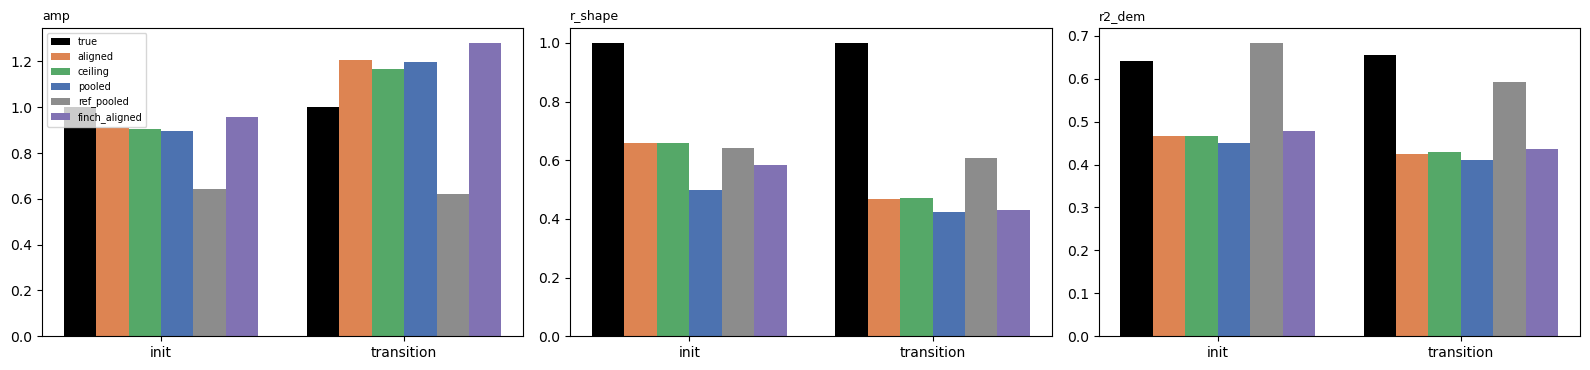

In [9]:
ALIGN168 = AL.Alignment(period_h=168, bin_h=None, block="phase")
OUT168 = {k: AL.analyse(world, CELLS[k], ALIGN168, store=store, server=True, n_perm=99)
          for k in RUNS}
display(pd.concat({k: v["summary"].set_index(["source", "phase"])[
    ["rmse", "r_shape", "amp", "r2_dem"]] for k, v in OUT168.items()}, axis=1).round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, OUT168[FOCUS]["summary"])
fig.tight_layout()
plt.show()

In [12]:
_ = AL.aligned_browser(OUT168[FOCUS]["run"], OUT168[FOCUS]["fid"], channels)

## 7. Invariance across blocks

Per weekday·hour class, each 6-month block against the init reference (the block's own months
left out). `r_true` is the data side and is the same for every cell; `e_lat` and `r_dec` are
the representation, so they differ by schedule.

In [11]:
BLOCK = 6
INV = {k: AL.invariance(world, OUTS[k]["run"], OUTS[k]["fw"], OUTS[k]["model"], channels,
                        block=BLOCK) for k in RUNS}
S_T = {k: AL.invariance_summary(v) for k, v in INV.items()}
INV_C = AL.invariance(world, san["control"].wt, fw, None, channels, block=BLOCK)

fig, axes = plt.subplots(len(S_T), 2, figsize=(16, 3.4 * len(S_T)), squeeze=False,
                         layout="constrained")
for i, (k, S) in enumerate(S_T.items()):
    im = AL.plot_invariance(axes[i, 0], S, "r_fid", "pure", vmin=-1, vmax=1)
    axes[i, 0].set_title(f"r_fid · pure · {k}", fontsize=9, loc="left")
    im2 = AL.plot_invariance(axes[i, 1], S, "e_lat", "pure", vmin=0, vmax=1, cmap="viridis")
    axes[i, 1].set_title(f"e_lat · {k}", fontsize=9, loc="left")
fig.colorbar(im, ax=axes[:, 0], shrink=0.6, label="r_fid")
fig.colorbar(im2, ax=axes[:, 1], shrink=0.6, label="e_lat")
plt.show()

display(pd.concat({k: v.pivot_table(index=["client", "slot_class"], columns="phase",
                                    values=["r_true", "r_fid", "e_lat"])
                   for k, v in S_T.items()}, axis=1).round(3))

AttributeError: 'AlignedRun' object has no attribute 'columns'

## 8. Drift visibility — the comparison

Per (client, month), two signals from each cell:

* **reconstruction**: median `r` and `rmse` over that month's windows;
* **latent displacement**: `e_lat` $=\lVert z_m - z_{ref}\rVert / \lVert z_{ref}\rVert$ and
  `cos_lat`, against the client's own init mean latent.

`visibility` reduces each to one number,

$$z = \frac{\mathrm{median}_{post} - \mathrm{median}_{ref}}{\mathrm{IQR}_{ref}}$$

with `post` from `first_switch` on, and `r` negated so that positive always means "moved".
`contrast` is the drifting client's $z$ minus the largest of the others: **a schedule is good
for drift detection when contrast is large**, i.e. it moves for A and not for B, C, D.

For the streaming cell there is a stronger signal still: each block is scored **before** it is
trained on, so `prequential` is an out-of-sample curve over time, and the honest latents of
that moment are in `latent_trajectories_preq`.

--- z per client, signal = e_lat


,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream
client,,,,,,
District_A,73.06,89.81,54.51,118.00,110.48,107.19
District_B,95.11,77.25,57.90,99.47,44.65,27.24
District_C,41.30,42.32,28.49,201.74,66.62,36.81
District_D,-0.09,-0.24,-0.30,0.09,-0.26,-0.21
contrast,-22.04,12.55,-3.39,-83.74,43.87,70.38


--- z per client, signal = r


,pw0·all,pw0·comm,pw0·stream,pw.1+s·all,pw.1+s·comm,pw.1+s·stream
client,,,,,,
District_A,5.92,179.66,-14.50,-3.22,93.69,-6.89
District_B,-5.86,65.93,-6.26,15.77,10.99,-9.77
District_C,-11.61,158.79,-1.05,-11.83,21.71,-5.06
District_D,0.10,-0.01,0.64,-0.04,-0.27,0.00
contrast,5.81,20.87,-15.14,-18.99,71.98,-6.90


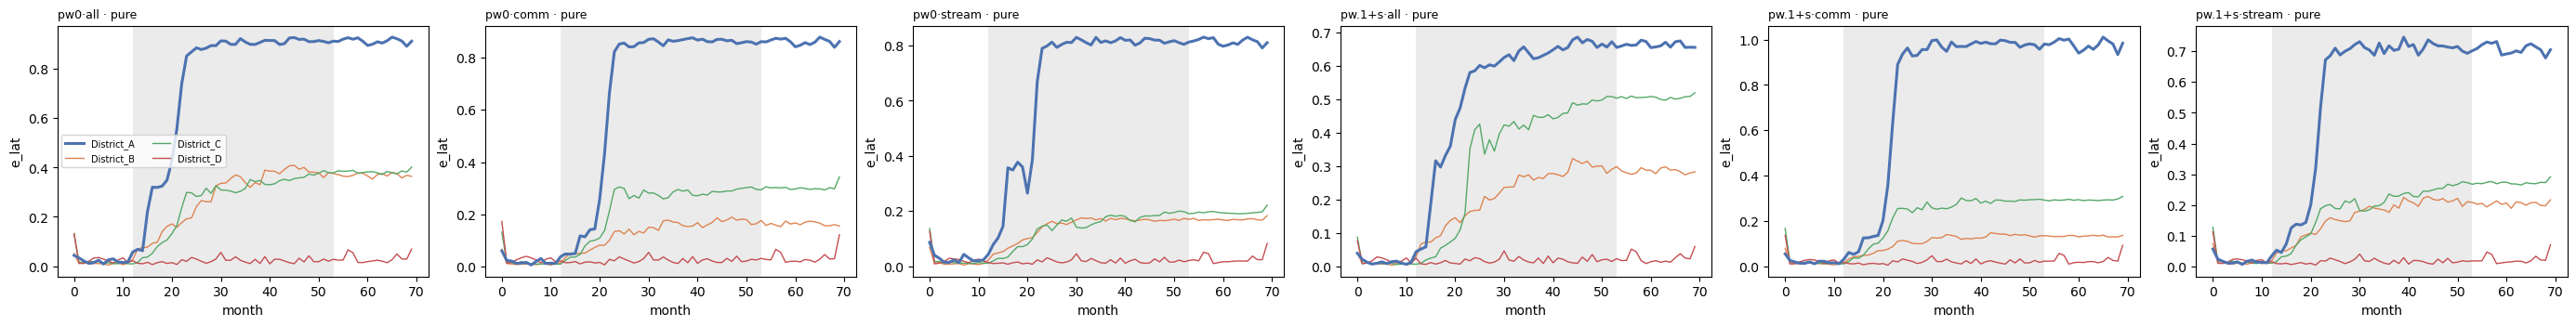

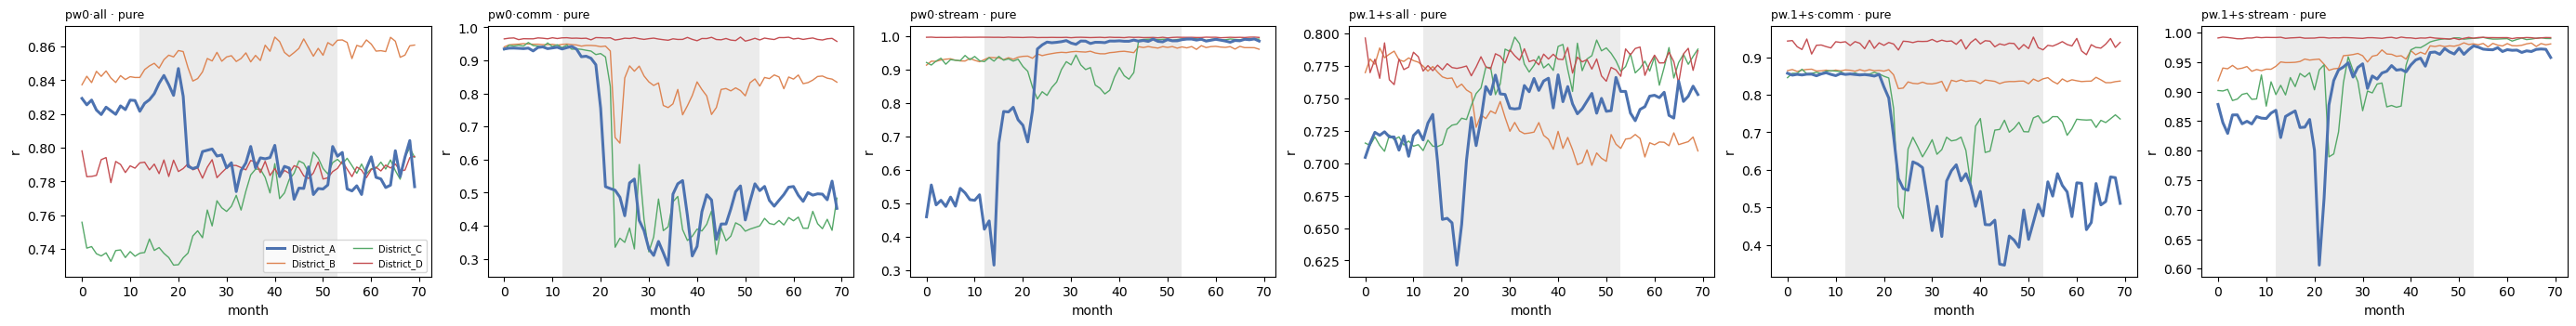

In [ ]:
PROF = {k: CP.drift_profile(world, OUTS[k]["run"], OUTS[k]["fw"], channels,
                            slot_class="pure") for k in RUNS}
VIS = {k: CP.visibility(PROF[k], world) for k in PROF}

for sig in ("e_lat", "r"):
    print(f"--- z per client, signal = {sig}")
    display(CP.compare_visibility(VIS, world, sig).round(2))

for sig in ("e_lat", "r"):
    fig, axes = plt.subplots(1, len(PROF), figsize=(4.6 * len(PROF), 3.4), squeeze=False,
                             layout="constrained")
    CP.plot_profiles(axes[0], PROF, world, sig, slot_note=" · pure")
    plt.show()

r         ratio       
model           global  local global  local
block m_lo m_hi                            
0     0    5    -0.017 -0.017  1.216  1.216
1     6    11   -0.006  0.019  0.952  0.859
2     12   17    0.796  0.850  0.243  0.165
3     18   23    0.895  0.907  0.327  0.310
4     24   29    0.793  0.803  0.289  0.275
5     30   35    0.800  0.822  0.238  0.222
6     36   41    0.861  0.883  0.159  0.138
7     42   47    0.864  0.874  0.134  0.128
8     48   53    0.938  0.945  0.075  0.070
9     54   59    0.951  0.953  0.059  0.056
10    60   65    0.965  0.967  0.043  0.040
11    66   69    0.971  0.972  0.036  0.034

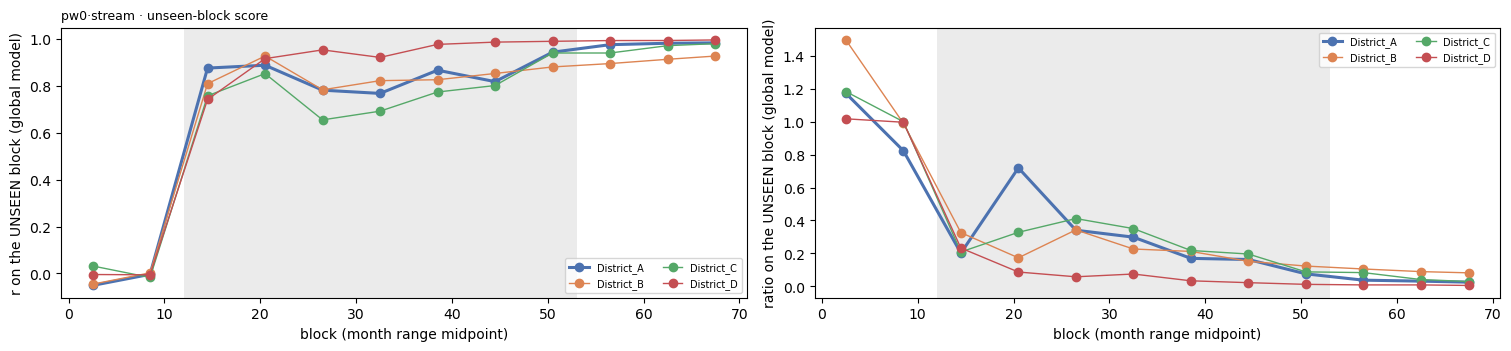

r         ratio       
model           global  local global  local
block m_lo m_hi                            
0     0    5    -0.017 -0.017  1.216  1.216
1     6    11    0.003  0.014  0.994  0.912
2     12   17    0.806  0.849  0.252  0.183
3     18   23    0.850  0.853  0.507  0.492
4     24   29    0.743  0.761  0.400  0.359
5     30   35    0.762  0.746  0.319  0.312
6     36   41    0.809  0.811  0.208  0.192
7     42   47    0.838  0.843  0.167  0.156
8     48   53    0.883  0.890  0.124  0.118
9     54   59    0.917  0.921  0.091  0.084
10    60   65    0.934  0.939  0.073  0.066
11    66   69    0.957  0.962  0.055  0.048

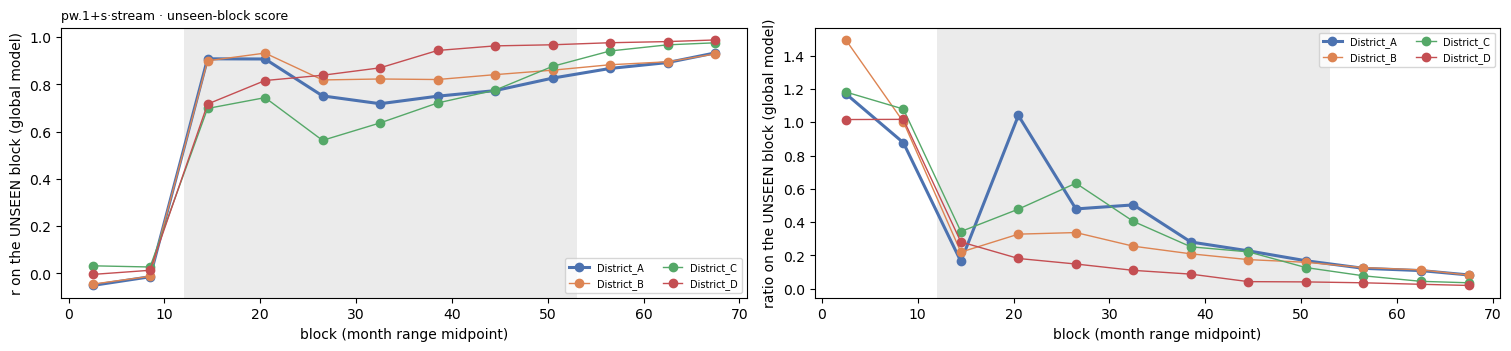

In [17]:
STREAM_CELLS = [k for k in RUNS if OUTS[k]["res"].get("prequential") is not None]
for k in STREAM_CELLS:
    preq = OUTS[k]["res"]["prequential"]
    display(preq.pivot_table(index=["block", "m_lo", "m_hi"], columns="model",
                             values=["r", "ratio"]).round(3))
    fig, ax = plt.subplots(1, 2, figsize=(15, 3.4), layout="constrained")
    CP.plot_prequential(ax[0], preq, world, "r")
    CP.plot_prequential(ax[1], preq, world, "ratio")
    ax[0].set_title(f"{k} · unseen-block score", fontsize=9, loc="left")
    plt.show()

## What to read out of this

* **Which schedule wins on `contrast`?** That is the thesis-relevant number: drift visible in
  the drifting client, quiet elsewhere. The all-months model can absorb the drift (it trains
  on it), so the expectation is `comm` ≥ `stream` > `all` on reconstruction-based signals, and
  a smaller difference on latent displacement.
* **Fidelity is the counterweight.** A commissioning model should be the best on init months
  and the worst afterwards. If it is also worse on init (fewer windows, so fewer steps despite
  the matched budget), the comparison is about data volume, not the schedule.
* **Prequential is the only out-of-sample number here.** Everything else, in every cell, is
  in-sample.

**Open after this:**
* the weekend modulation is a fidelity gap, not an averaging one; the levers are a smaller
  stride, the spectral term, or explicit calendar conditioning of the decoder (upstream);
* bidirectional sensors need their own encoding (magnitude plus direction);
* `final` is one month in this world, so the post-drift side rests on the transition blocks;
* a world with distinct sector maps is still what the regime-recovery question needs.